In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

proyectos = ["Piso Lima","Loft Miraflores","Casa Surco","Dpto Barranco"]
estados_cliente = ["Nuevo","Contactado","Calificado","Perdido"]
estados_civiles = ["Soltero","Casado","Divorciado","Unión Libre"]
niveles = ["Bajo","Medio","Alto"]
distritos = ["Lima Centro","Miraflores","Surco","Barranco","San Isidro"]
medios = ["Facebook Ads","Google Ads","Referidos","Web","Instagram"]

n = 300
df = pd.DataFrame({
    "proyecto": np.random.choice(proyectos, n),
    "estado_cliente": np.random.choice(estados_cliente, n),
    "estado_civil": np.random.choice(estados_civiles, n),
    "nivel_interes": np.random.choice(niveles, n),
    "distrito": np.random.choice(distritos, n),
    "valoracion": np.random.randint(1,6,size=n),
    "medio_captacion": np.random.choice(medios, n),
})



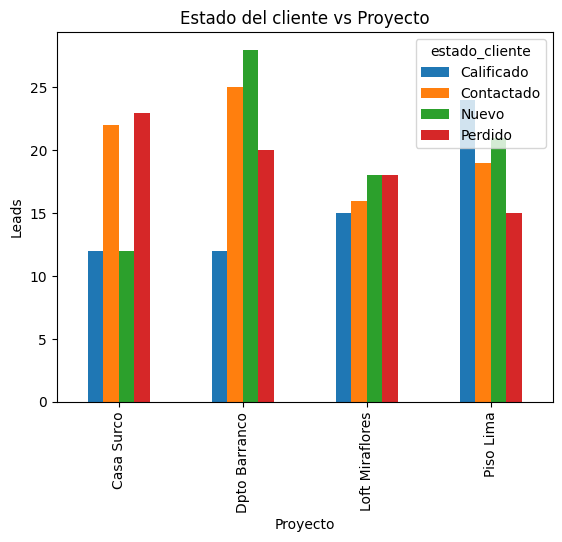

In [18]:
tabla1 = df.groupby(["proyecto","estado_cliente"]).size().unstack(fill_value=0)
tabla1.plot(kind='bar')
plt.title("Estado del cliente vs Proyecto")
plt.xlabel("Proyecto")
plt.ylabel("Leads")
plt.show()


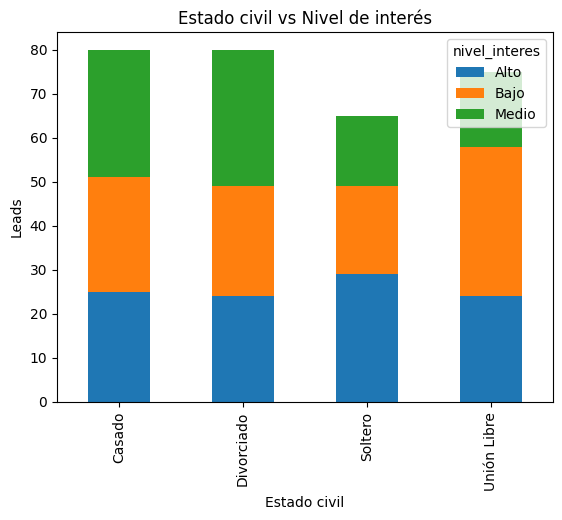

In [19]:
tabla2 = df.groupby(["estado_civil","nivel_interes"]).size().unstack(fill_value=0)
tabla2.plot(kind='bar', stacked=True)
plt.title("Estado civil vs Nivel de interés")
plt.xlabel("Estado civil")
plt.ylabel("Leads")
plt.show()


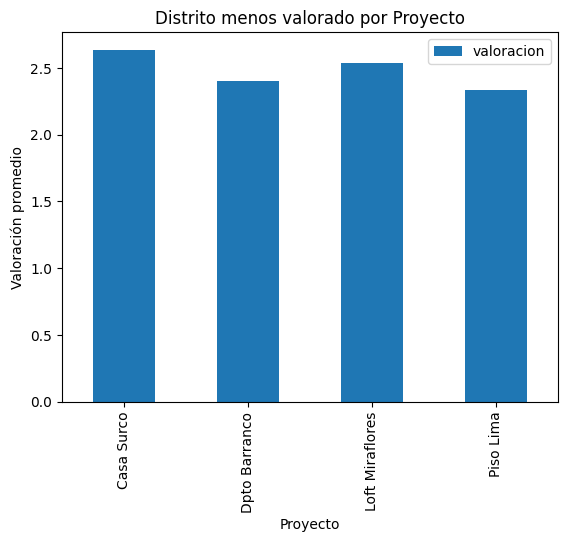

In [21]:
prom = df.groupby(["proyecto","distrito"])["valoracion"].mean().reset_index()
idx_min = prom.groupby("proyecto")["valoracion"].idxmin()
peor = prom.loc[idx_min].set_index("proyecto")

peor[["valoracion"]].plot(kind='bar')
plt.title("Distrito menos valorado por Proyecto")
plt.xlabel("Proyecto")
plt.ylabel("Valoración promedio")
plt.show()


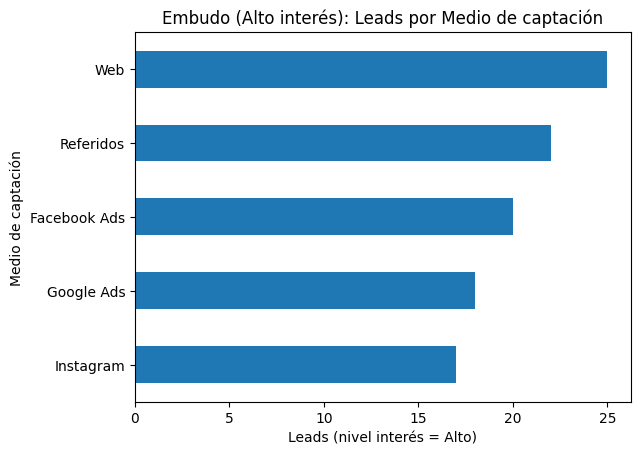

In [22]:
filtro = df[df["nivel_interes"]=="Alto"]
filtro["medio_captacion"].value_counts().sort_values(ascending=False).plot(kind='barh')
plt.title("Embudo (Alto interés): Leads por Medio de captación")
plt.xlabel("Leads (nivel interés = Alto)")
plt.ylabel("Medio de captación")
plt.gca().invert_yaxis()
plt.show()
